In [41]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path

In [3]:
BATCH = "008"

In [23]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"
NODES = Path("~/tesi/sarafu/final_simulations").expanduser() / BATCH

FIGURES = Path("~/papers/adtxns_paper/figures/new").expanduser()


In [5]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [6]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

In [13]:
from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [15]:
columns = ['tx_in','tx_out']
keyword = "-".join(columns)
data_sarafu = sarafu['agents'][columns].values

h1 = kde_scatter_estimate(data_sarafu, bw_method=0.2)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "kde" / f"{fname_sarafu}.pkl", "wb"))



In [16]:

# for s in metadata.s.unique():
#     for b in metadata.burstiness.unique():
for s in [1]:
    for b in tqdm(metadata.burstiness.unique(),colour="green"):
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation['agents'][columns].values
        h2 = kde_scatter_estimate(data_simu, bw_method=0.2)
        # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        fname_simu   = f"simulation__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

        pickle.dump(h2, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))


100%|██████████| 5/5 [01:28<00:00, 17.72s/it]


<Axes: xlabel='tx_in', ylabel='tx_out'>

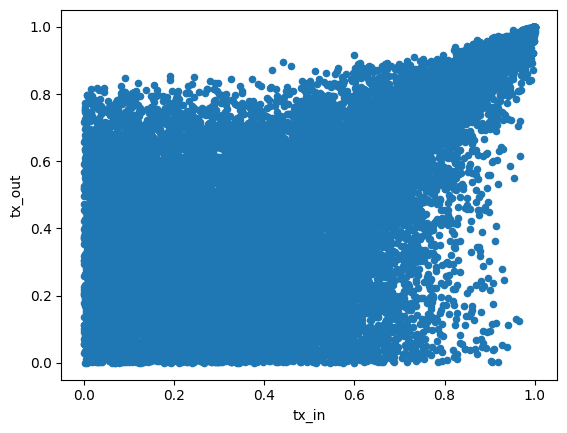

In [ ]:
# (sarafu['agents'][columns] + np.random.uniform(0,1,size=sarafu['agents'][columns].shape)).rank(pct=True).plot(
#     kind="scatter",
#     x="tx_in",
#     y="tx_out",
#     )

In [ ]:
#* copula for simulations 

columns = ['tx_in','tx_out']
keyword = "copula" + "-".join(columns)
data_sarafu = (sarafu['agents'][columns] + np.random.uniform(0,1,size=sarafu['agents'][columns].shape)).rank(pct=True).values

h1 = kde_scatter_estimate(data_sarafu, bw_method=0.2)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "kde" / f"{fname_sarafu}.pkl", "wb"))



# for s in metadata.s.unique():
#     for b in metadata.burstiness.unique():
for s in tqdm(metadata.s.unique(),colour="red"):
    for b in tqdm(metadata.burstiness.unique(),colour="green"):
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = (simulation['agents'][columns]  + np.random.uniform(0,1,size=simulation['agents'][columns].shape)).rank(pct=True).values
        h2 = kde_scatter_estimate(data_simu, bw_method=0.2)
        # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        fname_simu   = f"simulation__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

        pickle.dump(h2, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))


100%|██████████| 5/5 [00:56<00:00, 11.36s/it]


In [49]:
sarafu['agents'].columns

Index(['crid', 'tx_in', 'vol_in', 'mean_earn', 'median_earn', 'max_earn',
       'min_earn', 'mean_frac_in', 'median_frac_in', 'max_frac_in',
       'min_frac_in', 'in_deg', 'first_txns_in', 'tx_out', 'vol_out',
       'mean_exp', 'median_exp', 'max_exp', 'min_exp', 'mean_frac_out',
       'median_frac_out', 'max_frac_out', 'min_frac_out', 'out_deg',
       'first_txns_out'],
      dtype='object')

In [50]:
#* IN-OUT DEGREE

columns = ['in_deg','out_deg']
keyword = "-".join(columns)
data_sarafu = sarafu['agents'][columns].values

h1 = kde_scatter_estimate(data_sarafu, bw_method=0.2)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "kde" / f"{fname_sarafu}.pkl", "wb"))



# for s in metadata.s.unique():
#     for b in metadata.burstiness.unique():
for s in [1]:
    for b in tqdm(metadata.burstiness.unique(),colour="green"):
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation['agents'][columns].values
        h2 = kde_scatter_estimate(data_simu, bw_method=0.2)
        # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        fname_simu   = f"simulation__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

        pickle.dump(h2, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))


100%|██████████| 5/5 [00:45<00:00,  9.08s/it]


In [51]:
#* VOLUMES

columns = ['vol_in','vol_out']
keyword = "-".join(columns)
data_sarafu = sarafu['agents'][columns].values

h1 = kde_scatter_estimate(data_sarafu, bw_method=0.2)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "kde" / f"{fname_sarafu}.pkl", "wb"))



# for s in metadata.s.unique():
#     for b in metadata.burstiness.unique():
for s in [1]:
    for b in tqdm(metadata.burstiness.unique(),colour="green"):
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation['agents'][columns].values
        h2 = kde_scatter_estimate(data_simu, bw_method=0.2)
        # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        fname_simu   = f"simulation__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

        pickle.dump(h2, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))

100%|██████████| 5/5 [00:39<00:00,  7.91s/it]


In [17]:
import os

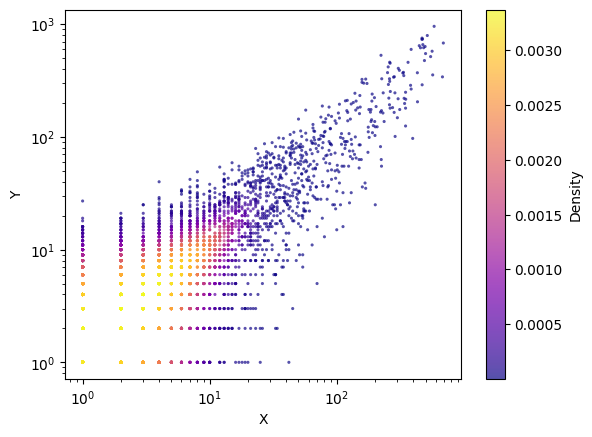

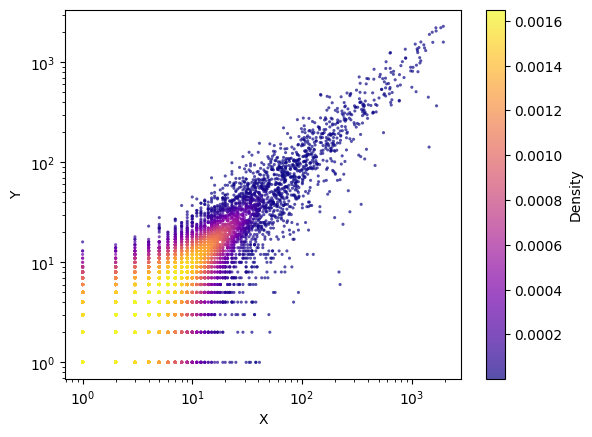

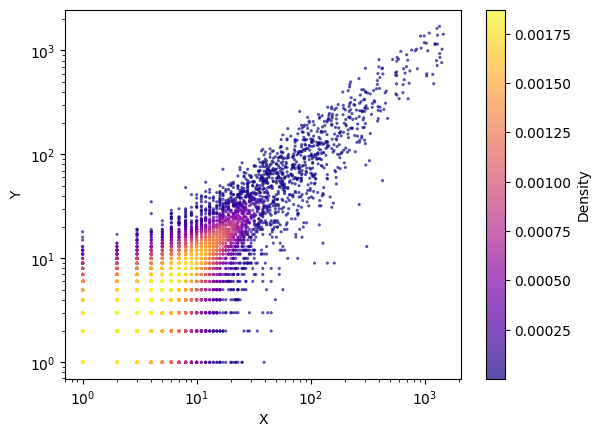

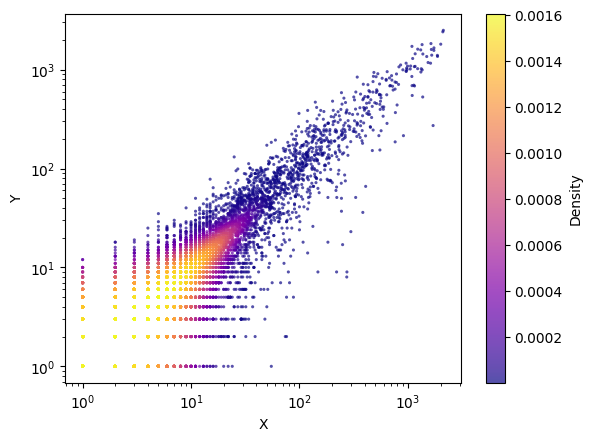

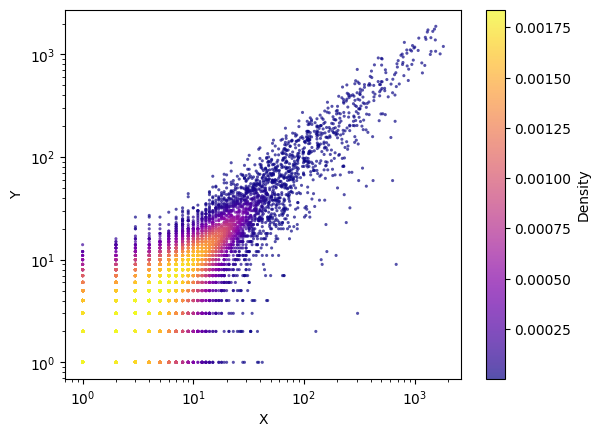

In [22]:
# for file in os.listdir(PICKLED / BATCH / "kde"):
#     # print(PICKLED / BATCH / "kde"/file)
#     fname = PICKLED / BATCH / "kde"/file
#     k = pickle.load(open(fname, "rb"))
#     ax, sc, cb = plot_scatter_from_kde(k, scatter_kw={"s": 5, "alpha": 0.7},log_scale=True)


In [ ]:
# # nodes = pd.read_csv(NODES / "nodes_{simu_id}.csv")
# # nodes.rename(columns={'act_pot': "e_tx_out", "att_pot": "e_tx_in"}, inplace=True)
# # data_nodes = nodes[['e_tx_in','e_tx_out']]
# keyword = 'act-attr'
# for s in [1]:
#     for b in tqdm(metadata.burstiness.unique(),colour="green"):
#         QUERY = f"s == {s} and burstiness == {b}"
#         meta_row = metadata.query(QUERY).iloc[0]
#         simu_id = meta_row.simulation_id
#         nodes = pd.read_csv(NODES / f"nodes_{simu_id}.csv")
#         nodes.rename(columns={'act_pot': "e_tx_out", "att_pot": "e_tx_in"}, inplace=True)
#         data_nodes = nodes[['e_tx_in','e_tx_out']].values
#         k = kde_scatter_estimate(data_nodes, bw_method=0.2)
#         # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
#         fname_simu   = f"nodes__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

#         pickle.dump(k, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))



100%|██████████| 5/5 [01:12<00:00, 14.49s/it]


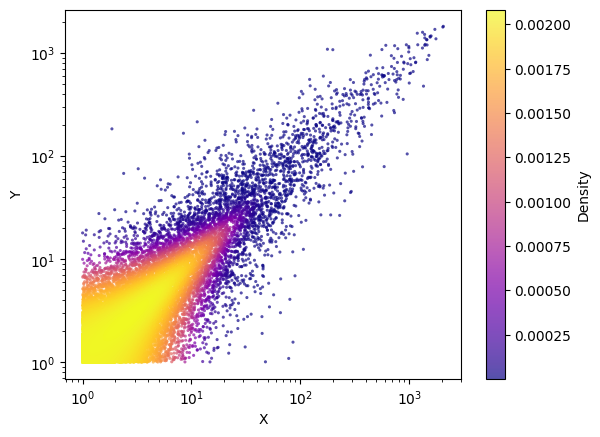

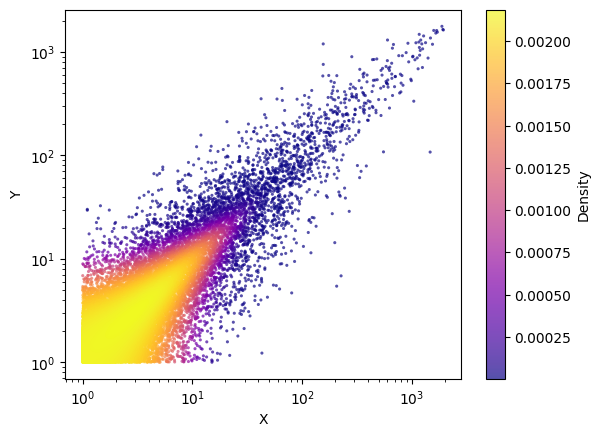

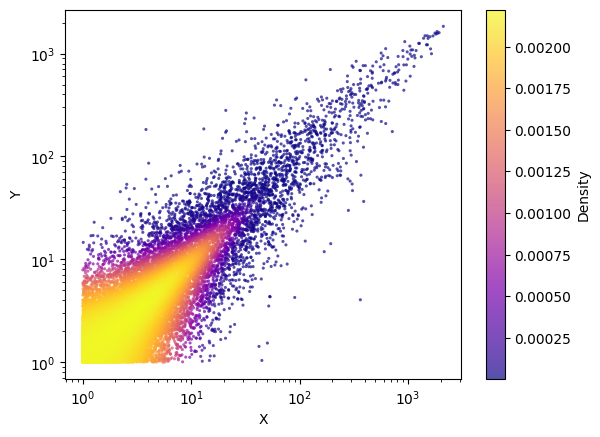

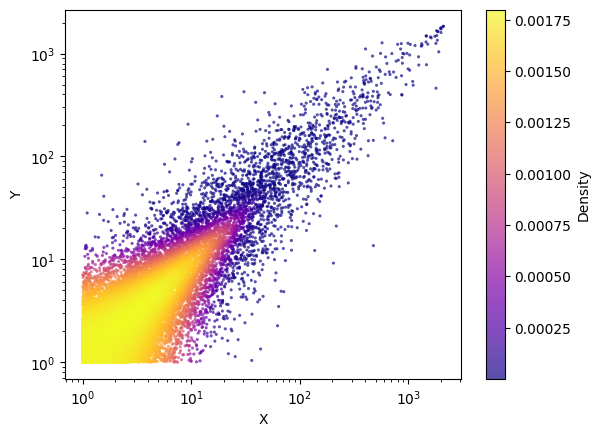

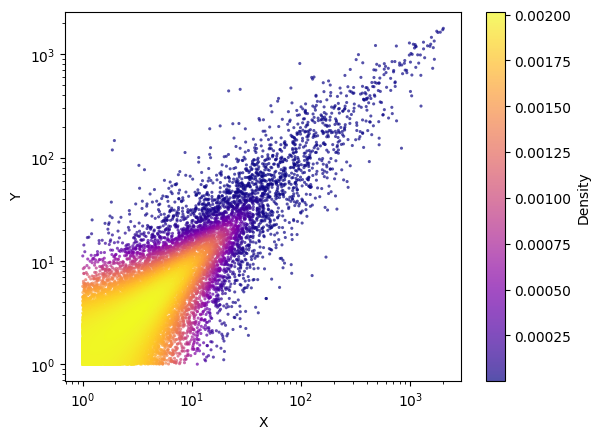

In [ ]:
# for file in os.listdir(PICKLED / BATCH / "kde"):
#     # print(PICKLED / BATCH / "kde"/file)
#     if file.startswith("nodes"):
#         fname = PICKLED / BATCH / "kde"/ file
#         k1 = pickle.load(open(fname, "rb"))
#         ax, sc, cb = plot_scatter_from_kde(k1, cmap="plasma", scatter_kw={"s": 5, "alpha": 0.7},log_scale=True)



In [ ]:
# test = 0
# if test:
#     nodes = pd.read_csv(NODES / "nodes_0.csv")
#     nodes.rename(columns={'act_pot': "e_tx_out", "att_pot": "e_tx_in"}, inplace=True)
#     data_nodes = nodes[['e_tx_in','e_tx_out']].rank(pct=True).values
#     k = kde_scatter_estimate(data_nodes, bw_method=0.2)
#     ax, sc, cb = plot_scatter_from_kde(k, cmap="plasma", scatter_kw={"s": 5, "alpha": 0.7},log_scale=False)

# else:
#     keyword = 'copula-act-attr'
#     for s in [1]:
#         for b in tqdm(metadata.burstiness.unique(),colour="green"):
#             QUERY = f"s == {s} and burstiness == {b}"
#             meta_row = metadata.query(QUERY).iloc[0]
#             simu_id = meta_row.simulation_id
#             nodes = pd.read_csv(NODES / f"nodes_{simu_id}.csv")
#             nodes.rename(columns={'act_pot': "e_tx_out", "att_pot": "e_tx_in"}, inplace=True)
#             data_nodes = nodes[['e_tx_in','e_tx_out']].rank(pct=True).values
#             k = kde_scatter_estimate(data_nodes, bw_method=0.2)
#             # fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
#             fname_simu   = f"nodes__{BATCH}__{simu_id}__metric={keyword}__s={s}__b={b}"

#             pickle.dump(k, open(PICKLED / BATCH / "kde" / f"{fname_simu}.pkl", "wb"))
# # 

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [02:08<00:00, 25.79s/it]


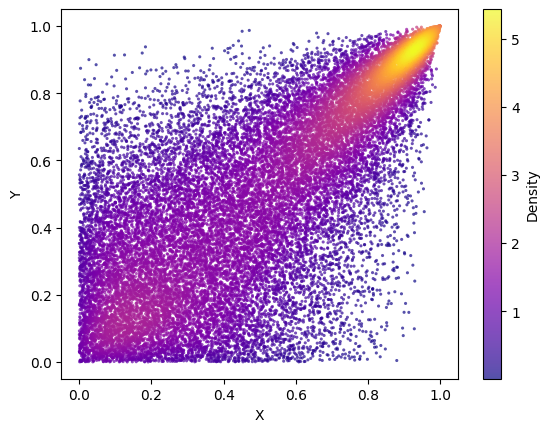

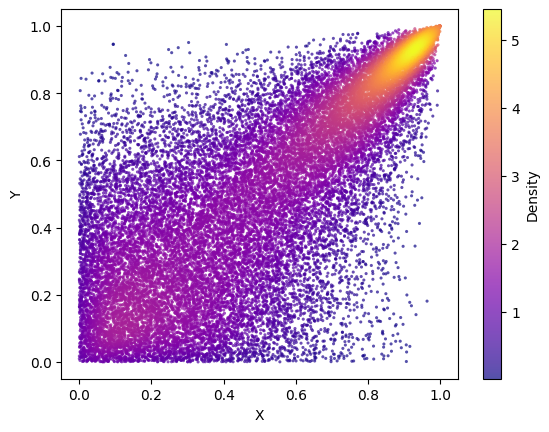

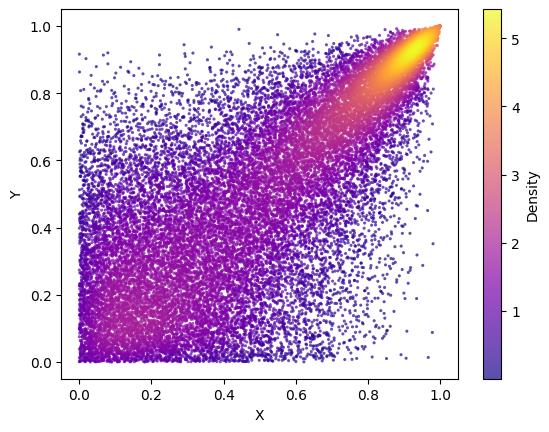

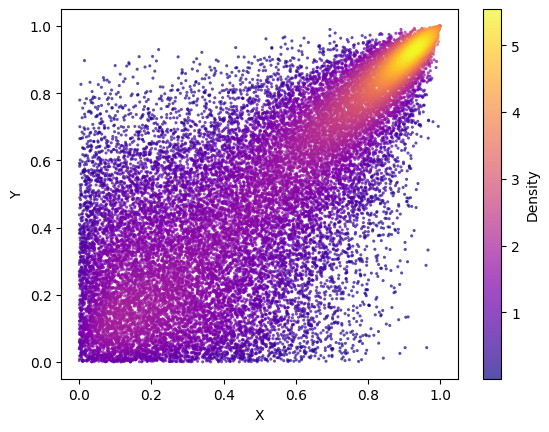

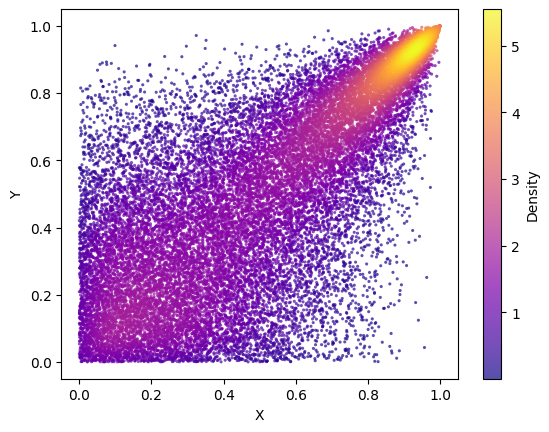

In [ ]:
# # matches = [s for s in os.listdir() if s.startswith("nodes") and "copula" in s]

# for file in os.listdir(PICKLED / BATCH / "kde"):
#     # print(PICKLED / BATCH / "kde"/file)
#     if (file.startswith("nodes")) and ("copula" in file):
#         fname = PICKLED / BATCH / "kde"/ file
#         k1 = pickle.load(open(fname, "rb"))
#         ax, sc, cb = plot_scatter_from_kde(k1, scatter_kw={"s": 5, "alpha": 0.7})

